---
title: Estimación de la Evapotranspiración con imágenes Sentinel
subject: Ejercicio
subtitle: Ejercicio que muestra cómo obtener mapas de Evapotranspiración real y estrés hídrico mediante el fusionado de productos de Copernicus
authors:
  - name: Héctor Nieto
    affiliations:
      - Instituto de Ciencias Agrarias, ICA
      - CSIC
    orcid: 0000-0003-4250-6424
    email: hector.nieto@ica.csic.es
  - name: Radoslaw Guzinski
    affiliations:
      - DHI
    orcid: 0000-0003-0044-6806
  - name: Benjamin Mary
    affiliation:
      - Instituto de Ciencias Agrarias
      - CSIC
    orcid: 0000-0003-0815-842X
label: nb-senet
license: CC-BY-SA-4.0
keywords: Evapotranspiration, TSEB, Sentinel-2, Sentinel-3, ECMWF
myst:
  enable_extensions: ["deflist", "attrs_block", "attrs_inline"]
jupytext:
  text_representation:
    extension: .md
    format_name: myst
    format_version: 0.13
    jupytext_version: 1.19.1
kernelspec:
  display_name: Python 3 (ipykernel)
  language: python
  name: python3
---

# La herramienta Sen-ET OpenEO toolbox
:::{note} Nota
Este proyecto está bajo desarrollo. Algunas funcionalidades pueden cambiar y pueden existir pequeños errores
:::

[**Sen-ET**](http://www.esa-sen4et.org/) es un marco de trabajo de código abierto para modelar la evapotranspiración real (ET) con alta resolución espacio-temporal utilizando datos de Sentinel y otros productos de Copernicus. Este repositorio contiene cuadernos Jupyter y scripts de Python para el modelado de ET de extremo a extremo mediante el marco Sen-ET, con acceso a datos de Sentinel y preprocesamiento inicial proporcionados a través de la API [openEO](https://documentation.dataspace.copernicus.eu/APIs/openEO/openEO.html) del [Ecosistema de Datos Copernicus](https://dataspace.copernicus.eu/) (CDSE).

::::{note} Nota
Las características de Sentinel-2 y Sentinel-3 son las siguientes

:::{table} Características de las misiones Sentinel-2 y Sentinel-3
:label: s2s3
Misión        | Rango espectral     | Número de bandas | Resolución espacial | Resolución temporal
:---          | :---                | :---             | :---                | :---            
Sentinel-2    | Visible, NIR, SWIR  | 10 (13)          | 10 -- 20 m          | 5 -- 10 días
Sentinel-3    | Visible, NIR, SWIR, TIR  | ~20 (VNIR) 2 (TIR)| 300m (VNIR) 1km (TIR)| 1 día
:::
::::

Esta implementación sigue el legado del [complemento SNAP Sen-ET](https://www.esa-sen4et.org/) original y de los paquetes Python de código abierto desarrollados para el modelado de ET. Actualmente se incluyen los siguientes módulos:
* [Data Mining Sharpener (pyDMS)](https://github.com/radosuav/pyDMS) - Implementación en Python del algoritmo Data Mining Sharpener (DMS): un algoritmo basado en árboles de decisión para el afilado (desagregación) de imágenes de baja resolución (p. ej., temperatura de superficie terrestre de Sentinel-3) usando imágenes de alta resolución (p. ej., reflectancia de Sentinel-2).
* [Two Source Energy Balance (TSEB)](https://github.com/hectornieto/pyTSEB) - Código Python para el modelo de Balance de Energía de Dos Fuentes (TSEB-PT) para estimar el flujo de calor sensible y latente (evapotranspiración) a partir de mediciones de temperatura radiométrica de la superficie.
* [Meteo Utils](https://github.com/hectornieto/meteo_utils/) - Métodos en Python que permiten la descarga y el procesamiento automático de datos de ECMWF relevantes para el modelado de la evapotranspiración.

## Instalación
### Instalación en el JupyterHub del Ecosistema de Datos Copernicus (CDSE)
Al ejecutarse en el [entorno JupyterHub de CDSE](https://jupyterhub.dataspace.copernicus.eu), las descargas de datos se minimizan, ya que los datos y el cómputo se encuentran en la misma infraestructura de nube.

1. Accede a [https://jupyterhub.dataspace.copernicus.eu](https://jupyterhub.dataspace.copernicus.eu) e inicia un servidor.
2. En el servidor, sube los cuadernos manualmente o clona este repositorio abriendo una terminal y ejecutando:
    ```bash
    git clone https://github.com/hectornieto/microcredencial-uclm.git mystorage/microcredencial
    ```
3. Instala todas las librerías requeridas usando los siguientes comandos en una terminal
    ```bash
    cd mystorage/microcredencial
    conda activate geo
    pip install -r requirements.txt
    ```  
4. Ejecuta los cuadernos usando un kernel que tenga GDAL instalado, p. ej. *Geo science*. Este paquete se instala en la primera celda de los cuadernos.

:::{warning} Aviso
 Deberías poder ejecutar los cuadernos sin ninguna configuración adicional si usas un kernel con GDAL instalado, pero a veces pueden surgir conflictos con paquetes existentes en el entorno. En ese caso, se recomienda hacer una instalación limpia del kernel siguiendo los pasos a continuación.
1. Crea un nuevo kernel limpio usando los siguientes comandos en una terminal de Jupyterhub:
    ```
    conda create -n gdal_env python=3.11 \
    conda activate gdal_env \
    conda install -c conda-forge gdal \
    pip install senet_toolbox@git+https://github.com/DHI/Sen-ET-OpenEO-toolbox.git \
    python -m ipykernel install --user --name=gdal_env --display-name "Sen-ET Kernel" 
    ```
2. Ahora puedes seleccionar el kernel "Sen-ET Kernel" para ejecutar los cuadernos.
:::

### Instalación local
Para instalar el Sen-ET OpenEO Toolbox de forma local, sigue estos pasos:

1. Instala GDAL
Asegúrate de que GDAL esté instalado en tu sistema. Es una dependencia obligatoria para el procesamiento de datos geoespaciales.

2. Instala el Toolbox desde GitHub
Una vez instalado GDAL, puedes instalar el toolbox directamente con pip:
    ```
    pip install senet_toolbox@git+https://github.com/DHI/Sen-ET-OpenEO-toolbox.git
    ```

# Recopilación de datos de entrada para el modelado de la evapotranspiración

En este cuaderno se recopilan los datos necesarios para ejecutar el modelado de la evapotranspiración desde el Ecosistema de Datos Copernicus (CDSE) usando la interfaz openEO.

Este cuaderno puede ejecutarse en el [Jupyterhub de Copernicus Dataspace](https://jupyterhub.dataspace.copernicus.eu), en cuyo caso no se realizan descargas locales de datos, ya que tanto los datos como el entorno de ejecución están en CDSE.

**Nota**: Debes seleccionar uno de los kernels con GDAL instalado, p. ej. "Geo science".

Primero comprobamos que el Sen-ET Toolbox esté instalado (y lo instalamos si es necesario) y luego importamos todos los paquetes necesarios.

In [1]:
try:
    import senet_toolbox
except ModuleNotFoundError:
    !pip install senet_toolbox@git+https://github.com/DHI/Sen-ET-OpenEO-toolbox.git

print("Sen-ET plugin instalado correctamente")

Sen-ET plugin instalado correctamente


In [2]:
from pathlib import Path
from dateutil.relativedelta import relativedelta
from shapely import to_geojson
from shapely.geometry import box
from osgeo import gdal
import rasterio
import openeo
import pandas as pd
from joblib import load
from rasterstats import zonal_stats
from senet_toolbox.utils import visualization, date_selector
from senet_toolbox.utils import raster_utils
from senet_toolbox.utils.general_utils import read_area_date_info, load_lut
from senet_toolbox.workflows import collect_input_data
from senet_toolbox.workflows import biophysical_processing
from senet_toolbox.workflows.prepare_ancillary_data import prepare_dem, prepare_lut_maps
from senet_toolbox.workflows.decision_tree_sharpener import sharpen_lst
from senet_toolbox.workflows.meteo_preprocessing import get_meteo_data
from ipywidgets import interact, interactive, fixed, widgets
from IPython.display import display
import datetime as dt
from pyTSEB.PyTSEB import PyTSEB
from datetime import datetime
import re
print("Librerías importadas correctamente, puedes continuar")

Librerías importadas correctamente, puedes continuar


## Seleccionar el Área de Interés
Para mantener los datos organizados y facilitar el procesamiento de series temporales, los datos de entrada y salida se guardan en carpetas de Área de Interés (AOI). Todos los datos dentro de una carpeta AOI tienen la misma extensión y cuadrícula.

En la celda siguiente, selecciona la ubicación donde deseas almacenar los datos y el nombre del AOI. Al ejecutar en el Jupyterhub de CDSE, se recomienda mantenerlo dentro de `./mystorage/`, de lo contrario los datos se borrarán entre sesiones.

Si estás configurando un nuevo AOI, usa la celda siguiente para dibujar un polígono en el mapa con la extensión que deseas procesar. Se recomienda seleccionar AOIs de aproximadamente 30 km × 30 km para que el afilado de LST funcione correctamente y el consumo de memoria no sea excesivo.

Si estás trabajando con un AOI existente, la celda simplemente visualizará el área.

In [3]:
data_dir = "./mystorage/302-SenET"
aoi_name = "agramon"
aoi_data_dir = Path(data_dir) / aoi_name

In [4]:
# Dibuja o visualiza la extensión del AOI al configurar uno nuevo
map, bboxs = visualization.select_aoi(aoi_data_dir)
map

Map(center=[38.4, -1.6], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out…

## Seleccionar fecha a partir de las adquisiciones disponibles de Sentinel-3

**Nota**: `max_cloud_cover` hace referencia a la cobertura de nubes de toda la tesela, no solo del AOI, por lo que los resultados pueden variar. Se recomienda también usar el [Navegador de Copernicus](https://browser.dataspace.copernicus.eu) para comprobar la disponibilidad de datos de Sentinel-3 y Sentinel-2 sobre el AOI dentro del rango temporal especificado.

In [5]:
# Definir parámetros de búsqueda
start_date = "2023-05-01"
end_date = "2023-05-10"
max_cloud_cover = 10 # Filtrar escenas con alta cobertura de nubes

# Buscar imágenes Sentinel-3 disponibles
date_selection = date_selector.select_date(
    aoi_data_dir = aoi_data_dir,
    start_date=start_date,
    end_date=end_date,
    max_cloud_cover=max_cloud_cover
)

Dropdown(description='Pick a Date:', index=1, options=(('2023-05-01', datetime.date(2023, 5, 1)), ('2023-05-10…

## Conectarse al backend de OpenEO

Las imágenes de Sentinel-3 y Sentinel-2, el mapa de cobertura del suelo Worldcover y el Modelo Digital de Elevación de Copernicus se descargan desde la interfaz OpenEO de CDSE. Ejecuta la celda siguiente para autenticarte en OpenEO.

**Nota:** Es posible que debas hacer clic en un enlace de autenticación que aparecerá y seguir las instrucciones.

In [6]:
connection = openeo.connect("https://openeo.dataspace.copernicus.eu")
connection.authenticate_oidc()

2026-04-27 16:25:42,023 [INFO] Loaded openEO client config from sources: []
2026-04-27 16:25:43,231 [INFO] Found OIDC providers: ['CDSE']
2026-04-27 16:25:43,231 [INFO] No OIDC provider given, but only one available: 'CDSE'. Using that one.
2026-04-27 16:25:43,696 [INFO] Using default client_id 'sh-b1c3a958-52d4-40fe-a333-153595d1c71e' from OIDC provider 'CDSE' info.
2026-04-27 16:25:43,697 [INFO] Found refresh token: trying refresh token based authentication.
2026-04-27 16:25:43,698 [INFO] Doing 'refresh_token' token request 'https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token' with post data fields ['grant_type', 'client_id', 'refresh_token'] (client_id 'sh-b1c3a958-52d4-40fe-a333-153595d1c71e')
2026-04-27 16:25:44,092 [INFO] Obtained tokens: ['token_type', 'access_token', 'expires_in', 'id_token', 'refresh_token', 'scope']
2026-04-27 16:25:44,093 [INFO] Storing refresh token for issuer 'https://identity.dataspace.copernicus.eu/auth/realms/CDSE' (c

Authenticated using refresh token.


<Connection to 'https://openeo.dataspace.copernicus.eu/openeo/1.2/' with OidcBearerAuth>

## Descargar datos de Sentinel-2 y Sentinel-3 para el AOI y la fecha especificados

Descarga la Temperatura de Superficie Terrestre (LST) y el Ángulo Zenital de Visión (VZA) de Sentinel-3, y los datos de reflectancia de Sentinel-2.

Al descargar Sentinel-2, mantén el ajuste `use_biopar_processor=True` para descargar también el índice de área foliar y otros parámetros biofísicos. El parámetro `sentinel2_search_range` indica cuántas fechas anteriores a la especificada se deben buscar datos de Sentinel-2. El archivo de salida contendrá el compuesto de píxeles más próximo sin nubes creado a partir de las fechas disponibles de Sentinel-2. Para acelerar el procesamiento, se recomienda usar el [Navegador de Copernicus](https://browser.dataspace.copernicus.eu) para revisar las imágenes de Sentinel-2 en la fecha especificada y antes de ella, y establecer este número lo más bajo posible.

:::{important} Importante
Para áreas grandes, la descarga y agregación de datos en OpenEO puede tardar bastante y podría fallar. Se recomienda procesar regiones más pequeñas a la vez.
Accede a [https://openeo.dataspace.copernicus.eu/](https://openeo.dataspace.copernicus.eu/) e inicia sesión para hacer seguimiento de los trabajos y ver posibles errores.
:::

In [7]:
s3_lst_path,s3_vza_path,s3_mask_path = collect_input_data.collect_sentinel3_data(
    connection=connection,
    bbox=bboxs[-1],
    date=date_selection.value,
    aoi_name=aoi_name,
    out_dir=data_dir,
)
print("Imagen de temperatura de superficide de Sentinel-3 descargada")

2026-04-27 16:25:46,986 [INFO] Cached Sentinel 3 data found. Skipping download.
2026-04-27 16:25:47,037 [INFO] Sentinel-3 data prepared and saved.


Imagen de temperatura de superficide de Sentinel-3 descargada


#### Ahora puedes visualizar la Temperatura de Superficie Terrestre (LST), el VZA o la Máscara de Sentinel-3

In [8]:
visualization.show_raster_map(
    s3_lst_path, # cambiar a s3_vza_path o s3_mask_path 
    cmap="inferno"
)

## Selecciona la fecha de Sentinel-2 más próxima para fusionar sus datos con Sentinel-3
El sistema va a buscar y procesar la fecha más cercana ($\pm5$ días) que coincida con la fecha elegida de Sentinel-3

In [9]:
s2_path = collect_input_data.collect_sentinel2_data(
    connection=connection,
    bbox=bboxs[-1],
    date=date_selection.value,
    aoi_name=aoi_name,
    out_dir=data_dir,
    sentinel2_search_range = 5,
    use_biopar_processor = True
)
print("Imagen de reflectividades de Sentinel-2 descargada")

2026-04-27 16:25:50,892 [INFO] Cached Sentinel 2 data found. Skipping download.
2026-04-27 16:25:50,893 [INFO] Sentinel-2 data prepared and saved.


Imagen de reflectividades de Sentinel-2 descargada


#### Visualiza los datos RGB de Sentinel-2 para confirmar que todo está correcto.


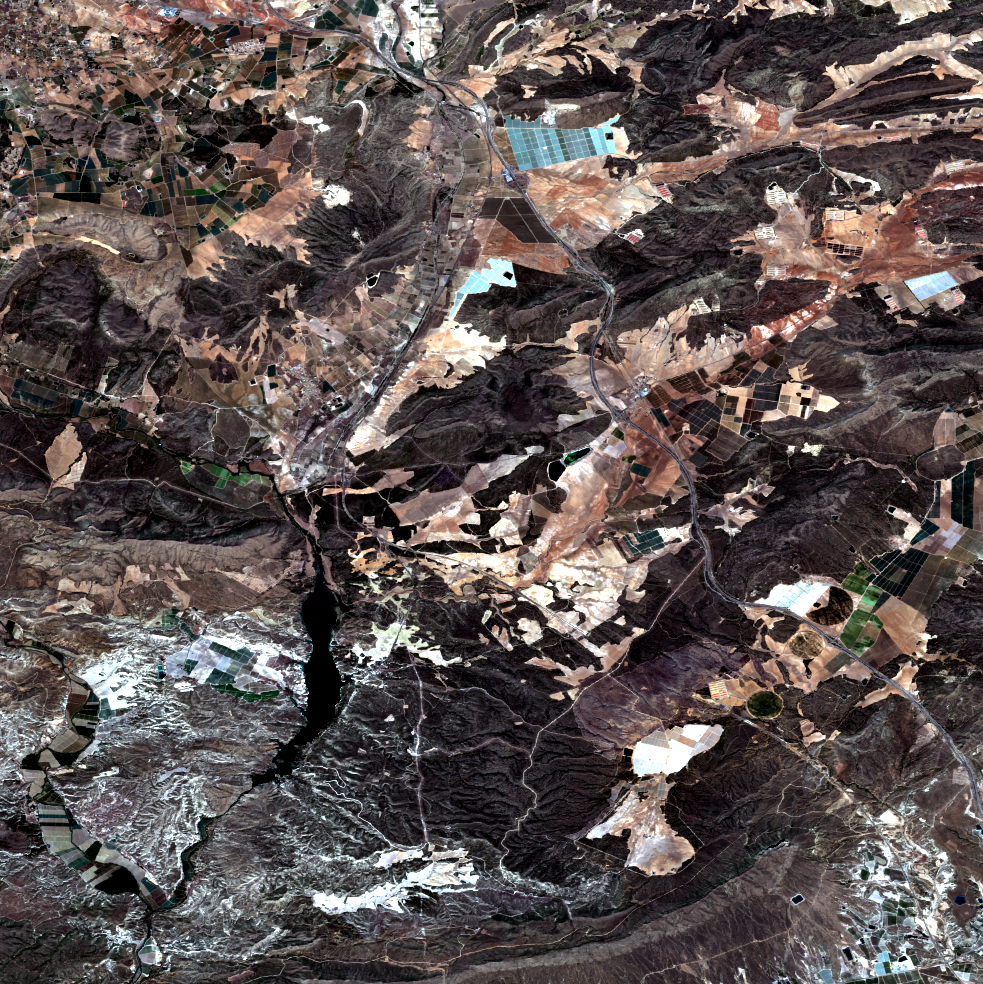

In [10]:
visualization.show_raster_map(
    s2_path,
    rgb=True
)

## Descargar datos estáticos del AOI

El mapa de cobertura del suelo Worldcover y el modelo digital de elevación no cambian con el tiempo, por lo que solo es necesario descargarlos una vez al configurar un nuevo AOI. Si estás trabajando con un AOI existente, puedes saltarte las dos celdas siguientes.

In [11]:
worldcover_path = collect_input_data.collect_worldcover_data(
    connection=connection,
    bbox=bboxs[-1],
    date=date_selection.value,
    aoi_name=aoi_name,
    s2_template_path=s2_path,
    out_dir=data_dir,
)
print("Mapa de cobertura del suelo descargado")

2026-04-27 16:25:57,188 [INFO] Cached Worldcover data found. Skipping download.
2026-04-27 16:25:57,189 [INFO] Worldcover data prepared and saved.


Mapa de cobertura del suelo descargado


#### Visualiza los datos de World Cover (aquí solo vemos el color; cada color representa una clase diferente en el conjunto de datos Worldcover).


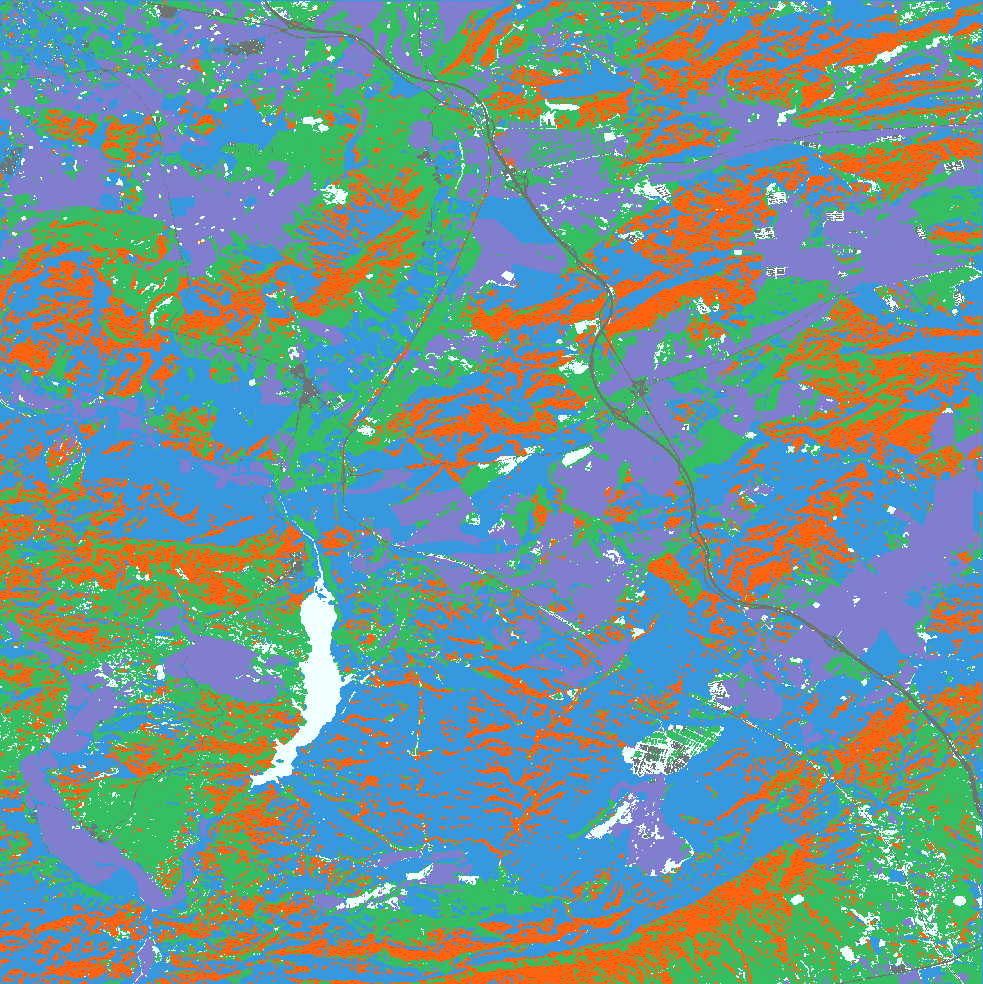

In [12]:
visualization.show_raster_map(
    worldcover_path,
    cmap="tab20c"
)

### Descarga el Modelo ditigal de elevaciones

In [13]:
dem_path = collect_input_data.collect_dem_data(
    connection=connection,
    bbox=bboxs[-1],
    date=date_selection.value,
    aoi_name=aoi_name,
    s2_template_path=s2_path,
    out_dir=data_dir,
)
print("Modelo Digital de Elevaciones descargado")

2026-04-27 16:26:01,138 [INFO] Cached DEM data found. Skipping download.
2026-04-27 16:26:01,139 [INFO] Copernicus DEM cube prepared and saved.


Modelo Digital de Elevaciones descargado


#### Visualiza el DEM


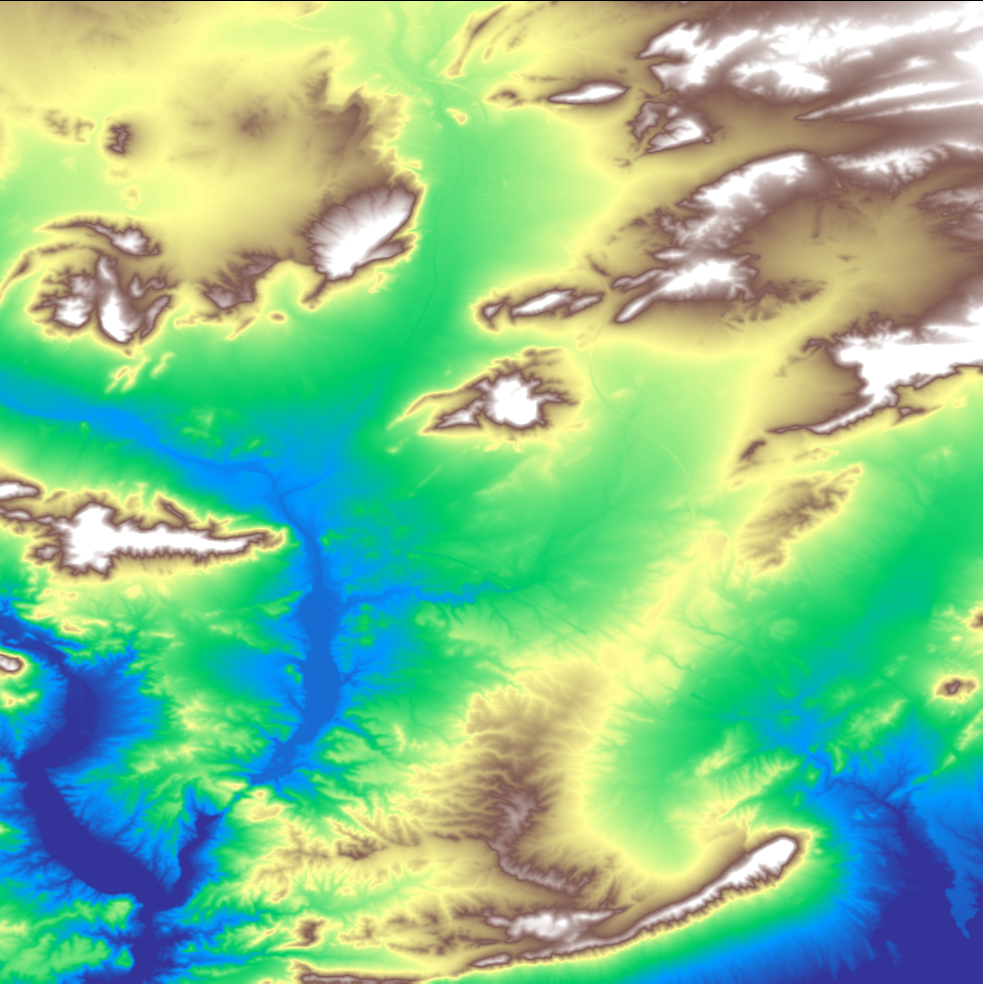

In [14]:
visualization.show_raster_map(
    dem_path,
    cmap="terrain",
    opacity=0.9
)

# Preparación de datos de entrada para el modelado de la evapotranspiración

En esta sección, los datos necesarios para el modelado de la evapotranspiración, recopilados en la sección anterior, se preprocesan para ser utilizados como entrada al modelo de evapotranspiración TSEB.

Para mantener los datos organizados y facilitar el procesamiento de series temporales, los datos de entrada y salida se guardan en carpetas de Área de Interés (AOI). Todos los datos dentro de una carpeta AOI tienen la misma extensión y cuadrícula.

En la celda siguiente, actualizamos la ubicación de los datos y el nombre del AOI establecidos en el la sección anterior. También se seleccionará automáticamente la última fecha procesada por ese cuaderno. 

In [15]:
date, bbox = read_area_date_info(dir=aoi_data_dir)
date = str(date)
date_data_dir = aoi_data_dir / date.replace("-", "")
s2_path = date_data_dir / f"s2_{date_data_dir.name}_data.nc"
worldcover_path = aoi_data_dir / "WorldCover2021.tif"
print(date)

2023-05-10


Si deseas trabajar con una fecha diferente, usa la siguiente celda para listar las fechas disponibles dentro del AOI para las que se han recopilado datos, selecciona la que desees en la lista desplegable y ejecuta la tercera celda para guardar tu elección.

In [16]:
# Ejecuta esta celda y la siguiente si deseas trabajar con una fecha diferente
date_selection = date_selector.get_collected_dates(
    aoi_data_dir = Path(data_dir) / aoi_name
)

Dropdown(description='Pick a Date:', options=(('2023-05-10', '2023-05-10'), ('2023-07-04', '2023-07-04')), val…

In [17]:
date = date_selection.value
date = str(date)
date_data_dir = aoi_data_dir / date.replace("-", "")
s2_path = date_data_dir / f"s2_{date_data_dir.name}_data.nc"
worldcover_path = aoi_data_dir / "WorldCover2021.tif"
print(date)

2023-05-10


## Preparar datos de entrada estáticos

Los datos de entrada derivados del Modelo Digital de Elevación (MDE) y del mapa de cobertura del suelo no cambian entre fechas, por lo que solo es necesario generarlos una vez al configurar un nuevo AOI.

::::{note} Nota
Por defecto, los parámetros estáticos se establecen según el mapa de cobertura del suelo Worldcover y la [tabla de correspondencia (LUT) por defecto](https://github.com/DHI/Sen-ET-OpenEO-toolbox/blob/main/senet_toolbox/static_data/WorldCover10m_2020_LUT.csv). 

:::{table}
Tabla de referencia para parámetros auxiliares según el tipo de cobertura

Clase | $h_{c,min}$ | $h_{c,max}$ | $LAI_{max}$ | $f_c$ | $w_c/h_c$ | tamaño hoja | LIDF | ¿herbáceo? | Clase IGBP | Descripción
---: | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | ---:
10 | 10 | 10 | 0 | 0.8 | 1.5 | 0.1 | 1 | 0 | 1 | Tree Cover
20 | 2 | 2 | 0 | 1 | 1 | 0.05 | 1 | 0 | 6 | Shrubland
30 | 0.1 | 1 | 4 | 1 | 1 | 0.02 | 0.5 | 1 | 10 | Grassland
40 | 0.15 | 1.5 | 5 | 1 | 1 | 0.02 | 0.5 | 1 | 12 | Cropland
41 | 0.1 | 0.9 | 5 | 1 | 1 | 0.02 | 0.5 | 1 | 12 | Durum Wheat
42 | 0.1 | 1 | 4 | 0.75 | 1 | 0.05 | 0.5 | 1 | 12 | Tomatoe
50 | 10 | 10 | 0 | 0 | 0 | 0 | 0 | 0 | 13 | Built-up
60 | 0.1 | 0.1 | 0 | 0 | 0 | 0 | 0 | 0 | 16 | Bare/Sparse Vegetation
70 | 0.1 | 0.1 | 0 | 0 | 0 | 0 | 0 | 0 | 15 | Snow and Ice
80 | 0.1 | 0.1 | 0 | 0 | 0 | 0 | 0 | 0 | 17 | Permanent water bodies
90 | 0.1 | 1 | 4 | 1 | 1 | 0.05 | 1 | 1 | 11 | Herbaceous wetland
95 | 5 | 5 | 0 | 0.7 | 1 | 0.1 | 0.7 | 0 | 11 | Mangroves
100 | 0.3 | 0.3 | 0 | 1 | 1 | 0.005 | 1 | 0 | 6 | Moss and lichen
210 | 0.3 | 0.7 | 4 | 1 | 1 | 0.02 | 0.8 | 1 | 12 | Peppermint
0 | 0.1 | 0.1 | 0 | 0 | 0 | 0 | 0 | 0 | 17 |  No data
:::
También puedes especificar rutas a tus propios mapas de cobertura del suelo (p.ej. SIOSE o SIGPAC) y tablas de correspondencia personalizadas (p. ej., que cubran cultivos o formaciones forestales específicas). Las columnas de la tabla personalizada deben ser iguales a las de la predeterminada y las filas deben coincidir con las clases presentes en el mapa de cobertura del suelo.
::::

In [18]:
prepare_dem(aoi_data_dir / "cdem.tif")
lut = load_lut()
prepare_lut_maps(worldcover_path, lut)
print("Todos los productos auxiliares generados")

/home/hectornieto/miniconda3/envs/uclm/lib/python3.11/site-packages/osgeo/gdal.py:606: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(
2026-04-27 16:26:08,691 [INFO] Saved raster: mystorage/302-SenET/agramon/W_C.tif
2026-04-27 16:26:08,692 [INFO] Saved veg_height_width_ratio to mystorage/302-SenET/agramon/W_C.tif
2026-04-27 16:26:08,769 [INFO] Saved raster: mystorage/302-SenET/agramon/LEAF_WIDTH.tif
2026-04-27 16:26:08,769 [INFO] Saved veg_leaf_width to mystorage/302-SenET/agramon/LEAF_WIDTH.tif
2026-04-27 16:26:08,840 [INFO] Saved raster: mystorage/302-SenET/agramon/F_C.tif
2026-04-27 16:26:08,841 [INFO] Saved veg_fractional_cover to mystorage/302-SenET/agramon/F_C.tif
2026-04-27 16:26:08,919 [INFO] Saved raster: mystorage/302-SenET/agramon/IGBP.tif
2026-04-27 16:26:08,919 [INFO] Saved igbp_classification to mystorage/302-SenET/agramon/IGBP.tif
2026-04-27 16:26:08,

Todos los productos auxiliares generados


## Procesamiento biofísico de datos Sentinel-2

Muchos de los parámetros biofísicos derivados de Sentinel-2 ya fueron recopilados en el cuaderno anterior. Aquí se guardan como archivos GeoTiff individuales y se utilizan para derivar los parámetros biofísicos restantes, como la fracción de vegetación verde, la altura del dosel o la reflectancia del dosel.

In [19]:
biophysical_processing.biopar_biophysical_params(s2_path, worldcover_path) 
print(f"Rasgos biofísicos generados a partir de {s2_path}")

2026-04-27 16:26:12,267 [INFO] Saved SCL to mystorage/302-SenET/agramon/20230510/20230510_SCL.tif
2026-04-27 16:26:12,284 [INFO] Saved sunZenithAngles to mystorage/302-SenET/agramon/20230510/20230510_SZA.tif
2026-04-27 16:26:12,361 [INFO] Saved LAI to mystorage/302-SenET/agramon/20230510/20230510_LAI.tif
2026-04-27 16:26:12,436 [INFO] Saved CCC to mystorage/302-SenET/agramon/20230510/20230510_CCC.tif
2026-04-27 16:26:12,508 [INFO] Saved CWC to mystorage/302-SenET/agramon/20230510/20230510_CWC.tif
2026-04-27 16:26:12,578 [INFO] Saved FAPAR to mystorage/302-SenET/agramon/20230510/20230510_FAPAR.tif
2026-04-27 16:26:12,849 [INFO] Saved raster: mystorage/302-SenET/agramon/20230510/20230510_F_G.tif
2026-04-27 16:26:12,850 [INFO] Saved frac_green to mystorage/302-SenET/agramon/20230510/20230510_F_G.tif
2026-04-27 16:26:12,970 [INFO] Saved raster: mystorage/302-SenET/agramon/20230510/20230510_H_C.tif
2026-04-27 16:26:12,971 [INFO] Saved H_C to mystorage/302-SenET/agramon/20230510/20230510_H_C

Rasgos biofísicos generados a partir de mystorage/302-SenET/agramon/20230510/s2_20230510_data.nc


## Afilado de la Temperatura de Superficie Terrestre de Sentinel-3

La Temperatura de Superficie Terrestre (LST) de Sentinel-3 se adquiere con una resolución espacial de aproximadamente 1 km. En este paso, se realiza una fusión de datos con la reflectancia de alta resolución de Sentinel-2, el MDE y las condiciones de iluminación derivadas del MDE, para obtener una representación de alta resolución de la LST.

:::{note} Nota
El parámetro `n_jobs` está establecido en 2 para acelerar el procesamiento. Sin embargo, para AOIs más grandes esto puede provocar un consumo excesivo de memoria y que el cuaderno falle. En ese caso, establece este parámetro en 1.
:::

In [20]:
n_jobs = 2

print(date_data_dir)

s2_refl_file = list(date_data_dir.glob("*_REFL.tif"))[0]
dem_path = aoi_data_dir / "cdem.tif"
for lst_file in date_data_dir.glob("*_LST.tif"):
    datetime_utc = datetime.strptime(re.search(r"_(\d{8}T\d{6})_", lst_file.stem).group(1), "%Y%m%dT%H%M%S")
    mask_file = Path(str(lst_file).replace("_LST.tif", "_mask.tif"))
    output_file = Path(str(lst_file).replace("_LST.tif", "_LST_sharpened.tif"))

    sharpened_data = sharpen_lst(
        high_res_optical_path=s2_refl_file,
        high_res_dem_path=dem_path,
        low_res_lst=lst_file,
        low_res_lst_mask=mask_file,
        mask_values=[1],
        datetime_utc=datetime_utc, 
        cv_homogeneity_threshold=0,
        moving_window_size=20,
        disaggregating_temperature=True,
        n_jobs=n_jobs,
        n_estimators=30,
        max_samples=0.8,
        max_features=0.8,
        output_path=output_file
    )

# Remuestrear VZA a la cuadrícula de Sentinel-2
for vza_file in date_data_dir.glob("*_VZA.tif"):
    raster_utils.resample_to_template(vza_file, vza_file, s2_refl_file)

print("Afilado de la temperatura finalizada")

2026-04-27 16:26:16,994 [INFO] Saved raster: mystorage/302-SenET/agramon/20230510/cos_theta_20230510T105300.tif


mystorage/302-SenET/agramon/20230510
Homogeneity CV threshold: 0.27
Number of training elements for is 529 representing 100% of avaiable low-resolution data.
Homogeneity CV threshold: 0.28
Number of training elements for is 207 representing 100% of avaiable low-resolution data.
Homogeneity CV threshold: 0.26
Number of training elements for is 207 representing 100% of avaiable low-resolution data.
Homogeneity CV threshold: 0.24
Number of training elements for is 81 representing 100% of avaiable low-resolution data.
Homogeneity CV threshold: 0.27
Number of training elements for is 529 representing 100% of avaiable low-resolution data.
0
1
2
3


2026-04-27 16:26:30,627 [INFO] Downscaled image saved to mystorage/302-SenET/agramon/20230510/s3_20230510T105300_LST_sharpened.tif
2026-04-27 16:26:30,629 [INFO] Starting resample_to_template...
2026-04-27 16:26:30,677 [INFO] Processing completed successfully.


LR residual bias: 0.20914510872091696
LR residual RMSD: 1.7709312626530231
Saving output...
Saved mystorage/302-SenET/agramon/20230510/s3_20230510T105300_LST_sharpened.tif
Afilado de la temperatura finalizada


#### Visualizar la LST afilada


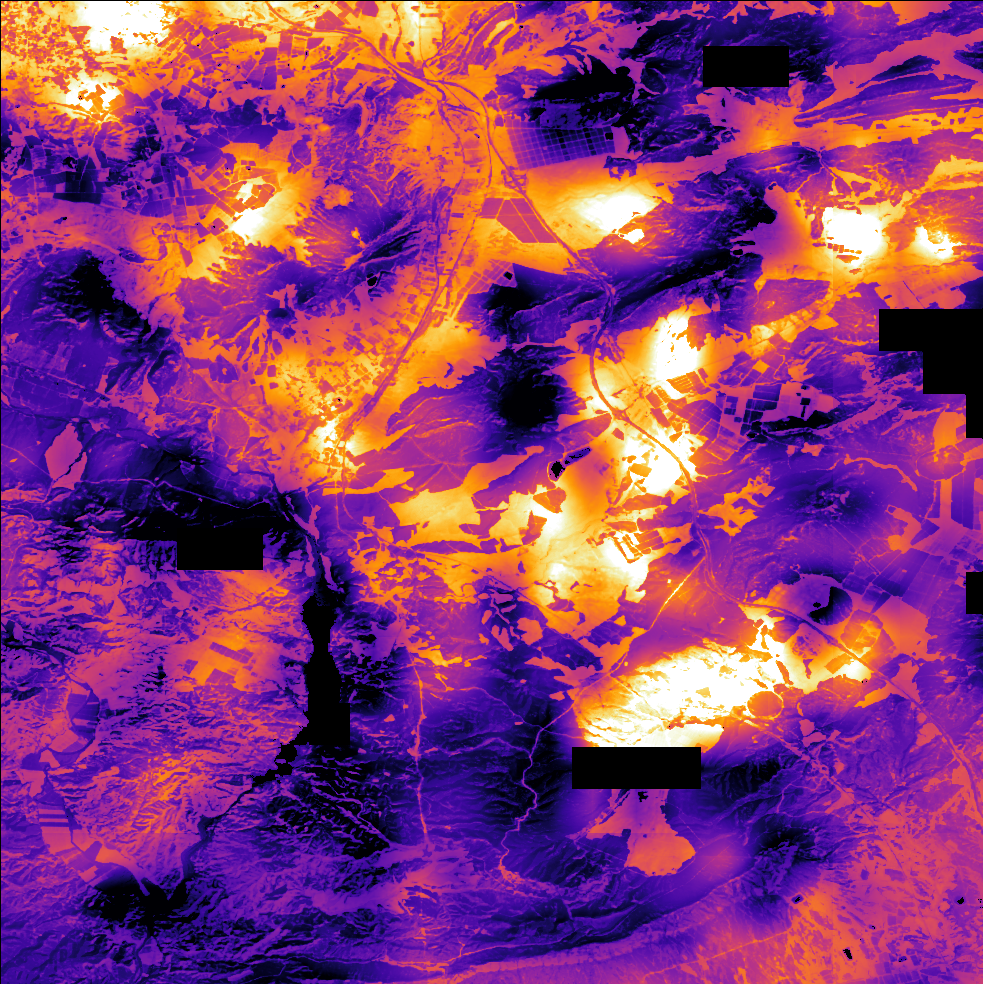

In [21]:
map = visualization.show_raster_map(
    output_file,
    cmap="inferno"
)
map

## Recopilación y preparación de datos meteorológicos
Los datos meteorológicos son los únicos datos que no se recopilan de CDSE mediante la interfaz openEO. En su lugar, provienen del [Copernicus Climate Service](https://cds.climate.copernicus.eu/) y del [Copernicus Atmospheric Service](https://cds.climate.copernicus.eu/). Para acceder a los datos de estas dos fuentes necesitas una clave de API, tal como se describe en la documentación:
* [Guía de usuario de CDS](https://cds.climate.copernicus.eu/how-to-api) 

Una vez que hayas creado las claves, guárdalas en los archivos ```key.adsapirc``` y ```key.cdsapirc``` con el formato que se muestra a continuación, y súbelos a `./mystorage` si ejecutas en el Jupyterhub de CDSE:

``` bash
key.adsapirc
url: https://ads.atmosphere.copernicus.eu/api
key: <api_key>
```
y
```` bash
key.cdsapirc
url: https://cds.climate.copernicus.eu/api
key: <api_key>
````

La celda siguiente descarga los datos, aplica correcciones basadas en el MDE a algunos parámetros y los remuestrea a la cuadrícula de Sentinel-2.

In [ ]:
template_file = list(date_data_dir.glob("*_LAI.tif"))[0]
for lst_file in date_data_dir.glob("*_LST.tif"):
    sentinel3_acq_datetime_str = re.search("_(\d{8}T\d{6})_", lst_file.stem).group(1)
    sentinel3_acq_datetime = datetime.strptime(sentinel3_acq_datetime_str, "%Y%m%dT%H%M%S")
    meteo_output_path = get_meteo_data(
        datetime = sentinel3_acq_datetime,
        bbox = bbox,
        dem_path = aoi_data_dir / "cdem_300.tif",
        template_path = template_file,
        data_dir=lst_file.parent,
        cds_credentials_file="./mystorage/key.cdsapirc",
        ads_credentials_file="./mystorage/key.adsapirc",
    )
print("Datos meteorológicos procesados")

2026-04-27 16:26:49,829 [INFO] Process era5 for single date'.


Querying products for extent [39.50015774553813, -2.700020461478738, 37.29803773116515, -0.49790044710575954]
..and dates 2023-05-09 10:53:00 to 2023-05-11 10:53:00


# Implementación del Modelo de Balance de Energía de Dos Fuentes (TSEB)

Este cuaderno implementa el **modelo de Balance de Energía de Dos Fuentes (TSEB)** de {cite:t}`tseb-norman1995` usando el paquete [pyTSEB](https://github.com/hectornieto/pyTSEB).

Procesa los datos de Temperatura de Superficie Terrestre (LST) afilados de Sentinel-3 junto con parámetros meteorológicos y de vegetación para calcular los flujos de energía de la superficie terrestre (incluyendo la evapotranspiración) a alta resolución espacial según {cite:t}`copernicus-guzinski2021`.

Para mantener los datos organizados y facilitar el procesamiento de series temporales, los datos de entrada y salida se guardan en carpetas de Área de Interés (AOI). Todos los datos dentro de una carpeta AOI tienen la misma extensión y cuadrícula.

In [54]:
date = str(date)
date = date.replace("-", "")
date_data_dir = aoi_data_dir / date
output_file = date_data_dir / "output" / f"TSEB-PT_{date}.vrt"
print(date)

20230704


Si deseas trabajar con una fecha diferente, usa la segunda celda para listar las fechas dentro del AOI para las que se han recopilado datos, selecciona la que desees en la lista desplegable y ejecuta la tercera celda para guardar tu elección.

In [55]:
date_selection = date_selector.get_collected_dates(
    aoi_data_dir = Path(data_dir) / aoi_name
)

Dropdown(description='Pick a Date:', options=(('2023-05-01', '2023-05-01'), ('2023-07-04', '2023-07-04')), val…

In [56]:
date = date_selection.value
date = date.replace("-", "")
date_data_dir = aoi_data_dir / date
output_file = date_data_dir / "output" / f"TSEB-PT_{date}.vrt"

Comprueba que la preparación de los datos de entrada se ha realizado correctamente y extrae el día del año y la hora del día de la adquisición de Sentinel-3, ya que estos parámetros son necesarios para ejecutar el TSEB.

In [57]:
lst_files = list(date_data_dir.glob("s3_*_LST_sharpened.tif"))
if not lst_files:
    raise FileNotFoundError(f"No se encontró ningún LST afilado de Sentinel-3 en {date_data_dir}. Ejecuta primero el paso 2.")

match = re.search(r"s3_(\d{8}T\d{6})_", lst_files[0].name)
date_time = match.group(1)

print("Marca temporal de observación detectada:", date_time)

## Convertir marca temporal
dt_obj = dt.datetime.strptime(date_time, "%Y%m%dT%H%M%S")

doy = dt_obj.timetuple().tm_yday
time_utc = dt_obj.hour + dt_obj.minute/60 + dt_obj.second/3600

print("Día del año:", doy)
print("Hora UTC:", time_utc)

Marca temporal de observación detectada: 20230704T102700
Día del año: 185
Hora UTC: 10.45


### Definir los parámetros del modelo TSEB
Aquí puedes especificar qué datos de entrada y otros parámetros debe usar el modelo TSEB. Puedes dejarlo tal cual si ejecutaste los demás cuadernos con los valores predeterminados y deseas usar la parametrización TSEB por defecto.

In [63]:
params = {
    "model": "TSEB_PT",
    "output_file": str(output_file),
    "T_R1": str(date_data_dir / f"s3_{date_time}_LST_sharpened.tif"),  # temperatura de superficie terrestre - debe ser el LST afilado de Sentinel-3
    "VZA": str(date_data_dir / f"s3_{date_time}_VZA.tif"),
    "input_mask": 1,
    "LAI": str(date_data_dir / f"{date}_LAI.tif"),
    "f_c": str(aoi_data_dir / "F_C.tif"),
    "h_C": str(date_data_dir / f"{date}_H_C.tif"),
    "w_C": str(aoi_data_dir / "W_C.tif"),
    "f_g": str(date_data_dir / f"{date}_F_G.tif"),
    "lat": str(aoi_data_dir / "lat.tif"),
    "lon": str(aoi_data_dir / "lon.tif"),
    "alt": str(aoi_data_dir / f"cdem.tif"),
    "stdlon": 0,
    "z_T": 100,
    "z_u": 100,
    "DOY": doy,
    "time": time_utc,
    "T_A1": str(date_data_dir / f"{date_time}_TA.tif"),
    "u": str(date_data_dir / f"{date_time}_WS.tif"),
    "p": str(date_data_dir / f"{date_time}_PA.tif"),
    "ea": str(date_data_dir / f"{date_time}_EA.tif"),
    "S_dn": str(date_data_dir / f"{date_time}_SW-IN.tif"),
    "S_dn_24": str(date_data_dir / f"{date}_SW-IN-DD.tif"),
    "emis_C": 0.99,
    "emis_S": 0.97,
    "tau_vis_C": str(date_data_dir / f"{date}_TAU_VIS_C.tif"),
    "rho_vis_C": str(date_data_dir / f"{date}_RHO_VIS_C.tif"),
    "rho_nir_C": str(date_data_dir / f"{date}_RHO_NIR_C.tif"),
    "tau_nir_C": str(date_data_dir / f"{date}_TAU_NIR_C.tif"),
    "rho_vis_S": 0.15,
    "rho_nir_S": 0.25,
    "alpha_PT": 1.26,
    "x_LAD": str(aoi_data_dir / "X_LAD.tif"),
    "z0_soil": 0.01,
    "landcover": str(aoi_data_dir / "IGBP.tif"),
    "leaf_width": str(aoi_data_dir/ "LEAF_WIDTH.tif"),
    "resistance_form": 0,
    "KN_b": 0.012,
    "KN_c": 0.0038,
    "KN_C_dash": 90,
    "G_form": [[1], 0.35], # Relación constante del 35% - válido cuando la adquisición de LST es alrededor del mediodía
    "water_stress": 0,
    "calc_row": [1, 90],
    "row_az": 90,
}

print("Input listos para TSEB")

Input listos para TSEB


### Ejecutar el modelo TSEB

Finalmente podemos ejecutar el modelo de evapotranspiración TSEB. El archivo de salida `ET_day` representa la evapotranspiración diaria en unidades de mm/día.

In [64]:
model = PyTSEB(params)
results = model.process_local_image()

Estimating missing SZA parameter
Estimating missing SAA parameter
Estimating missing L_dn parameter
Processing...
Iteration: 0, non-converged pixels: 905827, max L diff: inf, total time: 0.000680, loop time: 0.000678
Iteration: 1, non-converged pixels: 905819, max L diff: inf, total time: 1.744589, loop time: 1.743909
Iteration: 2, non-converged pixels: 905819, max L diff: 4.685503, total time: 3.714981, loop time: 1.970393
Iteration: 3, non-converged pixels: 905819, max L diff: 0.587348, total time: 5.757576, loop time: 2.042595
Iteration: 4, non-converged pixels: 887212, max L diff: 0.300806, total time: 7.798124, loop time: 2.040548
Iteration: 5, non-converged pixels: 874348, max L diff: 0.304033, total time: 9.553332, loop time: 1.755208
Iteration: 6, non-converged pixels: 866619, max L diff: 0.277352, total time: 11.091449, loop time: 1.538117
Iteration: 7, non-converged pixels: 574447, max L diff: 0.213973, total time: 12.476532, loop time: 1.385084
Iteration: 8, non-converged pi

El modelo genera dos carpetas distinas:

* `./output/TSEB-PT_<fecha>.data` donde se guardan los flujos de agua y energía principales
  - `TSEB-PT_<fecha>_ET_day.tif` la ET real diaria (mm/día).
  - `TSEB-PT_<fecha>_LE1.tif` el flujo de calor latente ($\lambda E$) a la hora de adquisición (W/m²).
  - `TSEB-PT_<fecha>_H1.tif` el flujo de calor sensible ($H$) a la hora de adquisición (W/m²).
  - `TSEB-PT_<fecha>_R_n1.tif` la radiación neta ($R_n$) a la hora de adquisición (W/m²).
  - `TSEB-PT_<fecha>_G1.tif` el flujo de calor almacenado en el suelo ($G$) a la hora de adquisición (W/m²).

* `./output/TSEB-PT_<fecha>_ancillary.data` donde se guardan salidas del modelo auxiliares. De entre esas destacamos:
  - `TSEB-PT_<fecha>_flag.tif` calificadores de calidad de las salidas del modelo (`255-->descartar`).
  - `TSEB-PT_<fecha>_LE_C1.tif` el flujo de calor latente de la vegetación ($\lambda E_C$) a la hora de adquisición (W/m²).
  - `TSEB-PT_<fecha>_LE_partition.tif` la proporción de transpiración sobre evapotranspiración total.
  - `TSEB-PT_<fecha>_T_C1.tif` la temperatura de la vegetación estimada a la hora de adquisición (K).
  - `TSEB-PT_<fecha>_T_S1.tif` la temperatura del suelo estimado a la hora de adquisición (K).

#### Visualiza el mapa de ET diaria.


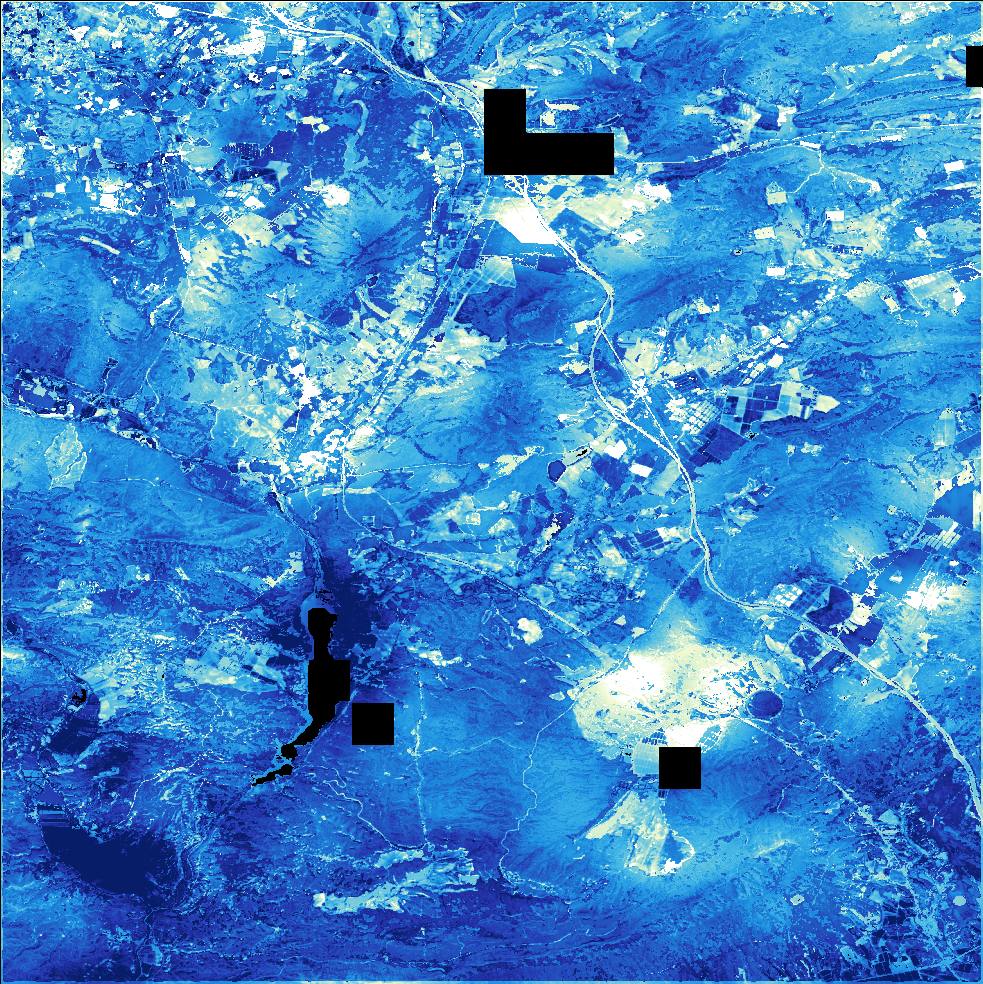

In [65]:
map = visualization.show_raster_map(
    output_file.parent / f"{output_file.stem}.data/{output_file.stem}_ET_day.tif",
    cmap="YlGnBu"
)
map

# Ejercicio
1. Genera tu propia zona de interés la región que quieras evaluar.
2. Estima la ET corriendo este cuaderno en una o dos fechas críticas (p.ej primavera y verano o dos años climatológicamente distintos)
4. Genera un pequeño informe de 1-2 páginas detallando conclusiones sobre las tendencias espaciales observadas
5. Exporta todo el cuaderno en formato pdf

## Entregables
* Informe de la imágenes de ET y las diferencias observadas entre las fechas
* El cuaderno digital en formato pdf